# 🚀 Practice Day 08

**📅 Date:** 2026-09-20  
**📁 Category:** Phase 2 · SQL 중급 JOIN/CASE WHEN/서브쿼리 (Round 1/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Practice explicit SQL JOIN syntax across 2 and 3 tables (명시적 JOIN 문법을 2개, 3개 테이블에 적용)
- Use CASE WHEN to build conditional labels inside a query (CASE WHEN으로 쿼리 안에서 조건별 라벨 만들기)
- Use a subquery to filter based on an aggregate value (집계값 기준으로 필터링하는 서브쿼리 작성)
- Same dataset as Day 7 — compare how the same questions feel in SQL vs. the Pandas merge() you already did (Day 7과 같은 데이터셋 — 같은 질문을 SQL로 풀 때 Pandas merge()와 어떻게 다른지 비교)

---
# 📂 Dataset

**Dataset Name:** E-commerce Customers / Products / Orders (이커머스 고객·상품·주문 데이터)

**Source:** Synthetically generated for practice, fixed random seed — identical generation code to Day 7, so this is the exact same data (연습용으로 코드에서 직접 생성, seed 고정 — Day 7과 생성 코드가 동일한 같은 데이터입니다)

**Description:** Same three related tables as Day 7. `customers_df` (45 customers: NYC neighborhood, signup date, membership tier), `products_df` (23 products across 5 categories; unit_price in USD), and `orders_df` (280 orders, each linking one customer_id and one product_id). This time you'll answer the questions with SQL JOINs instead of pd.merge().
(Day 7과 동일한 세 테이블입니다. customers_df(고객 45명: 뉴욕 동네·가입일·등급), products_df(상품 23개, 5개 카테고리, 단가 USD), orders_df(주문 280건, 각 주문은 customer_id 1개와 product_id 1개를 참조). 이번엔 pd.merge() 대신 SQL JOIN으로 풀어봅니다.)

## Dataset Preview

In [7]:
# Dataset Preview
import pandas as pd
import numpy as np
from IPython.display import display

np.random.seed(42)

# --- customers_df (identical to Day 7) ---
n_customers = 45
first_names = ['James', 'Emma', 'Liam', 'Olivia', 'Noah', 'Ava', 'Ethan', 'Sophia', 'Mason', 'Mia',
                'Lucas', 'Amelia', 'Henry', 'Harper', 'Alexander', 'Isabella', 'Benjamin', 'Charlotte', 'Daniel', 'Evelyn']
last_names = ['Smith', 'Johnson', 'Williams', 'Brown', 'Jones', 'Garcia', 'Miller', 'Davis', 'Wilson', 'Taylor']
customer_names = [f'{np.random.choice(first_names)} {np.random.choice(last_names)}' for _ in range(n_customers)]
regions = ['SoHo', 'Williamsburg', 'Midtown', 'Chelsea', 'Astoria', 'Upper West Side']
region_weights = [0.32, 0.26, 0.13, 0.09, 0.10, 0.10]

customers_df = pd.DataFrame({
    'customer_id': [f'CUST-{i+1:03d}' for i in range(n_customers)],
    'customer_name': customer_names,
    'region': np.random.choice(regions, size=n_customers, p=region_weights),
    'signup_date': pd.to_datetime('2024-01-01') + pd.to_timedelta(np.random.randint(0, 550, n_customers), unit='D'),
    'membership_tier': np.random.choice(['Regular', 'Silver', 'Gold'], size=n_customers, p=[0.55, 0.30, 0.15]),
})

# --- products_df (identical to Day 7) ---
product_catalog = {
    'Electronics': [('Wireless Mouse', 25), ('Bluetooth Speaker', 45), ('USB-C Hub', 32), ('Webcam', 55), ('Desk Lamp', 28)],
    'Home & Kitchen': [('Ceramic Mug Set', 18), ('Non-stick Pan', 39), ('Storage Container Set', 22), ('Electric Kettle', 42), ('Cutting Board', 15)],
    'Sports & Outdoors': [('Yoga Mat', 24), ('Water Bottle', 12), ('Resistance Bands', 16), ('Running Shorts', 21), ('Foam Roller', 27)],
    'Beauty': [('Facial Cleanser', 14), ('Moisturizer', 26), ('Sunscreen', 18), ('Lip Balm Set', 9)],
    'Books': [('Business Strategy Guide', 19), ('Novel Collection', 15), ('Cookbook', 21), ('Self-Help Book', 13)],
}
prod_rows = []
pid = 1
for cat, items in product_catalog.items():
    for name, price in items:
        prod_rows.append({'product_id': f'PROD-{pid:02d}', 'product_name': name, 'category': cat, 'unit_price': price})
        pid += 1
products_df = pd.DataFrame(prod_rows)

# --- orders_df (identical to Day 7) ---
n_orders = 280
customer_popularity = np.random.dirichlet(np.ones(n_customers) * 1.5)
product_popularity = np.random.dirichlet(np.ones(len(products_df)) * 1.5)

orders_df = pd.DataFrame({
    'order_id': [f'ORD-{i+1:05d}' for i in range(n_orders)],
    'customer_id': np.random.choice(customers_df['customer_id'], size=n_orders, p=customer_popularity),
    'product_id': np.random.choice(products_df['product_id'], size=n_orders, p=product_popularity),
    'order_date': np.random.choice(pd.date_range('2026-01-01', '2026-06-30', freq='D'), size=n_orders),
    'quantity': np.random.choice([1, 2, 3, 4, 5], size=n_orders, p=[0.45, 0.30, 0.15, 0.07, 0.03]),
})
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
orders_df = orders_df.sort_values('order_date').reset_index(drop=True)

print('customers_df:', customers_df.shape)
display(customers_df.head())
print('\nproducts_df:', products_df.shape)
display(products_df.head())
print('\norders_df:', orders_df.shape)
display(orders_df.head())

customers_df: (45, 5)


,customer_id,customer_name,region,signup_date,membership_tier
0,CUST-001,Ethan Brown,Chelsea,2025-05-20,Regular
1,CUST-002,Alexander Davis,Chelsea,2024-12-13,Gold
2,CUST-003,Ethan Taylor,SoHo,2025-04-17,Regular
3,CUST-004,Daniel Miller,Williamsburg,2024-08-18,Silver
4,CUST-005,Lucas Davis,SoHo,2024-07-08,Silver



products_df: (23, 4)


,product_id,product_name,category,unit_price
0,PROD-01,Wireless Mouse,Electronics,25
1,PROD-02,Bluetooth Speaker,Electronics,45
2,PROD-03,USB-C Hub,Electronics,32
3,PROD-04,Webcam,Electronics,55
4,PROD-05,Desk Lamp,Electronics,28



orders_df: (280, 5)


,order_id,customer_id,product_id,order_date,quantity
0,ORD-00186,CUST-037,PROD-07,2026-01-03,1
1,ORD-00248,CUST-001,PROD-09,2026-01-03,1
2,ORD-00229,CUST-027,PROD-10,2026-01-03,1
3,ORD-00153,CUST-016,PROD-19,2026-01-04,2
4,ORD-00216,CUST-027,PROD-13,2026-01-04,5


## Dataset Information

In [8]:
# Dataset Information
import duckdb

for name, d in [('customers_df', customers_df), ('products_df', products_df), ('orders_df', orders_df)]:
    print(f'=== {name}: {d.shape} ===')
    d.info()
    print()

# This file focuses on JOIN / CASE WHEN / subqueries. Quick JOIN syntax example
# (this just counts rows - it doesn't answer any of the business questions):
duckdb.sql('''
    SELECT COUNT(*) AS joined_row_count
    FROM orders_df o
    JOIN products_df p ON o.product_id = p.product_id
''').show()

=== customers_df: (45, 5) ===
<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      45 non-null     str           
 1   customer_name    45 non-null     str           
 2   region           45 non-null     str           
 3   signup_date      45 non-null     datetime64[us]
 4   membership_tier  45 non-null     str           
dtypes: datetime64[us](1), str(4)
memory usage: 1.9 KB

=== products_df: (23, 4) ===
<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_id    23 non-null     str  
 1   product_name  23 non-null     str  
 2   category      23 non-null     str  
 3   unit_price    23 non-null     int64
dtypes: int64(1), str(3)
memory usage: 868.0 bytes

=== orders_df: (280, 5) ===
<class

---
# ❓ Business Questions

1. For each order, what is the customer's name and membership tier? (각 주문에 대해 고객명과 등급은?)
2. Classify each order as 'High Value' (total price >= $100) or 'Regular' - how many orders fall into each? (주문별 총액이 $100 이상이면 'High Value', 아니면 'Regular'로 분류하면 각각 몇 건인가?)
3. Which products have a unit price above the average unit price across all products? (전체 상품 평균 단가보다 비싼 상품은?)
4. What is the average order value (unit_price × quantity) for each membership tier? (등급별 평균 주문 금액은?)
5. What is the total monthly revenue trend? (월별 총 매출 추이는?)

---
# 🛠 Skills Used
- [x] Python
- [ ] NumPy
- [x] Pandas — `.df()`, `sort_values`
  (SQL 결과를 DataFrame으로, 차트용 정렬)
- [x] SQL — `JOIN`, `CASE WHEN`, subquery, `GROUP BY`, `AVG`/`COUNT`/`SUM`, `DATE_TRUNC`
  (`JOIN`, `CASE WHEN`, 서브쿼리, 집계, 월 자르기)
- [x] Matplotlib
- [ ] Other: 

---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 0 on all three tables
  (세 테이블 모두 결측 없음)
- [x] Duplicate Rows — 0
  (중복 행 없음. 고객명 unique는 43, id는 45)
- [x] Wrong Data Types — ids/names/region/tier/category are text; unit_price and quantity are int; dates are datetime
  (텍스트, 가격·수량은 정수, 날짜는 datetime)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [9]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("===== customers_df =====")
print("Missing values")
print(customers_df.isnull().sum())
print("\nDuplicate rows:", customers_df.duplicated().sum())
print("\nDtypes")
print(customers_df.dtypes)
print("\nColumn names")
print(customers_df.columns.tolist())
obj_cols = customers_df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(customers_df[obj_cols].nunique())
print()

print("===== products_df =====")
print("Missing values")
print(products_df.isnull().sum())
print("\nDuplicate rows:", products_df.duplicated().sum())
print("\nDtypes")
print(products_df.dtypes)
print("\nColumn names")
print(products_df.columns.tolist())
obj_cols = products_df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(products_df[obj_cols].nunique())
print()

print("===== orders_df =====")
print("Missing values")
print(orders_df.isnull().sum())
print("\nDuplicate rows:", orders_df.duplicated().sum())
print("\nDtypes")
print(orders_df.dtypes)
print("\nColumn names")
print(orders_df.columns.tolist())
obj_cols = orders_df.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(orders_df[obj_cols].nunique())
print()


===== customers_df =====
Missing values
customer_id        0
customer_name      0
region             0
signup_date        0
membership_tier    0
dtype: int64

Duplicate rows: 0

Dtypes
customer_id                   str
customer_name                 str
region                        str
signup_date        datetime64[us]
membership_tier               str
dtype: object

Column names
['customer_id', 'customer_name', 'region', 'signup_date', 'membership_tier']

Text columns — unique counts
customer_id        45
customer_name      43
region              6
membership_tier     3
dtype: int64

===== products_df =====
Missing values
product_id      0
product_name    0
category        0
unit_price      0
dtype: int64

Duplicate rows: 0

Dtypes
product_id        str
product_name      str
category          str
unit_price      int64
dtype: object

Column names
['product_id', 'product_name', 'category', 'unit_price']

Text columns — unique counts
product_id      23
product_name    23
category        

---
# 📊 Analysis

## Question 1

**Question:** For each order, what is the customer's name and membership tier? (각 주문에 대해 고객명과 등급은?)

**Result:** After `JOIN` on `customer_id`, the table has **280** rows (one per order) with `customer_name` and `membership_tier`. The same name and tier repeat when that customer ordered more than once. Cleaning unique counts: orders use **42** of **45** customer_ids.
(`JOIN` 후 280행. 같은 고객이 여러 주문에 반복. 주문에 나온 고객 id는 45명 중 42명)

**Insight:** Q1 is a lookup at order grain, not a customer list. Do not count repeated names as extra people. Three customers never appear because they have no order row.
(Q1은 주문 단위 조회. 이름이 반복되어도 사람 수가 늘어난 것이 아님. 주문 없는 고객 3명은 안 나옴)

In [10]:
# Question 1: JOIN orders_df with customers_df ON customer_id, using duckdb.sql()
# SELECT customer_name, membership_tier per order
# (duckdb.sql()로 SQL 쿼리 작성)

duckdb.sql("SELECT o.order_id, c.customer_name, c.membership_tier FROM orders_df o JOIN customers_df c ON o.customer_id = c.customer_id").df()

,order_id,customer_name,membership_tier
0,ORD-00186,Sophia Jones,Silver
1,ORD-00248,Ethan Brown,Regular
2,ORD-00229,Harper Smith,Gold
3,ORD-00153,Evelyn Wilson,Gold
4,ORD-00216,Harper Smith,Gold
...,...,...,...
275,ORD-00236,Amelia Davis,Regular
276,ORD-00244,Mia Brown,Gold
277,ORD-00086,Liam Jones,Regular
278,ORD-00046,Lucas Davis,Silver


## Question 2

**Question:** Classify each order as 'High Value' (total price >= $100) or 'Regular' - how many orders fall into each? (주문별 총액이 $100 이상이면 'High Value', 아니면 'Regular'로 분류하면 각각 몇 건인가?)

**Result:** Regular **258** orders, High Value **22** orders.
(Regular 258건, High Value 22건)

**Insight:** High Value is a small tail (**22** of **280**). Do not treat $100 as a typical order.
(High Value는 꼬리. 100달러를 보통 주문으로 보면 안 됨)

In [11]:
# Question 2: JOIN orders_df with products_df, compute total price, then CASE WHEN to label
# 'High Value' (>= 100) vs 'Regular', then GROUP BY the label and COUNT
# (duckdb.sql()로 SQL 쿼리 작성)

duckdb.sql("""
SELECT
    CASE WHEN o.quantity * p.unit_price >= 100 THEN 'High Value' ELSE 'Regular' END AS order_type,
    COUNT(*) AS order_count
FROM orders_df o
JOIN products_df p ON o.product_id = p.product_id
GROUP BY order_type
""").df()


,order_type,order_count
0,Regular,258
1,High Value,22


## Question 3

**Question:** Which products have a unit price above the average unit price across all products? (전체 상품 평균 단가보다 비싼 상품은?)

**Result:** **9** products: Wireless Mouse **$25**, Bluetooth Speaker **$45**, USB-C Hub **$32**, Webcam **$55**, Desk Lamp **$28**, Non-stick Pan **$39**, Electric Kettle **$42**, Foam Roller **$27**, Moisturizer **$26**.
(평균보다 비싼 상품 9개)

**Insight:** This is catalog unit price vs the catalog average, not sales mix. All five Electronics SKUs are on the list. Do not read these as best-sellers.
(카탈로그 단가 vs 평균. 판매량 아님. Electronics 5개가 전부 포함. 잘 팔리는 상품으로 읽지 말 것)

In [22]:
# Question 3: Use a subquery inside WHERE - unit_price > (SELECT AVG(unit_price) FROM products_df)
# (duckdb.sql()로 SQL 쿼리 작성, 서브쿼리 사용)

duckdb.sql("""
SELECT * 
FROM products_df 
WHERE unit_price > (SELECT AVG(unit_price) FROM products_df)
""").df().sort_values('unit_price', ascending=False)

,product_id,product_name,category,unit_price
3,PROD-04,Webcam,Electronics,55
1,PROD-02,Bluetooth Speaker,Electronics,45
6,PROD-09,Electric Kettle,Home & Kitchen,42
5,PROD-07,Non-stick Pan,Home & Kitchen,39
2,PROD-03,USB-C Hub,Electronics,32
4,PROD-05,Desk Lamp,Electronics,28
7,PROD-15,Foam Roller,Sports & Outdoors,27
8,PROD-17,Moisturizer,Beauty,26
0,PROD-01,Wireless Mouse,Electronics,25


---
# 📈 Visualization

**Chart 1:** Average order value by membership tier (bar chart) — 등급별 평균 주문 금액

**Interpretation:** Gold **$47.95**, Regular **$47.75**, Silver **$44.26**. The three bars are close. Do not read Gold as a much higher AOV tier.
(Gold 47.95, Regular 47.75, Silver 44.26. 세 막대가 비슷. Gold를 훨씬 큰 객단가로 보지 말 것)

---

**Chart 2:** Total monthly revenue trend (line chart) — 월별 총 매출 추이

**Interpretation:** Feb is the peak (**$2,589**). Jan is the low (**$1,914**). Mar **$2,101**, Apr **$2,134**, May **$2,383**, Jun **$2,028**. This is not a steady rise.
(2월이 최고, 1월이 최저. 우상향 추세가 아님)

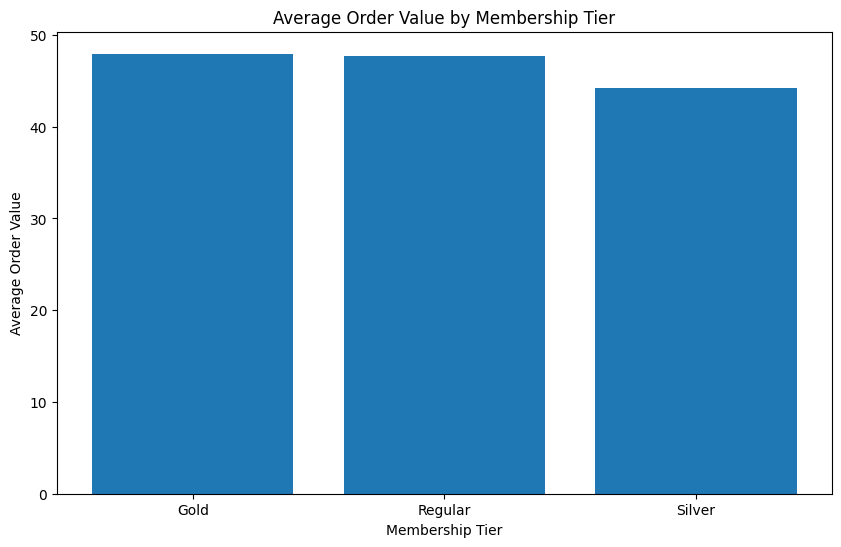

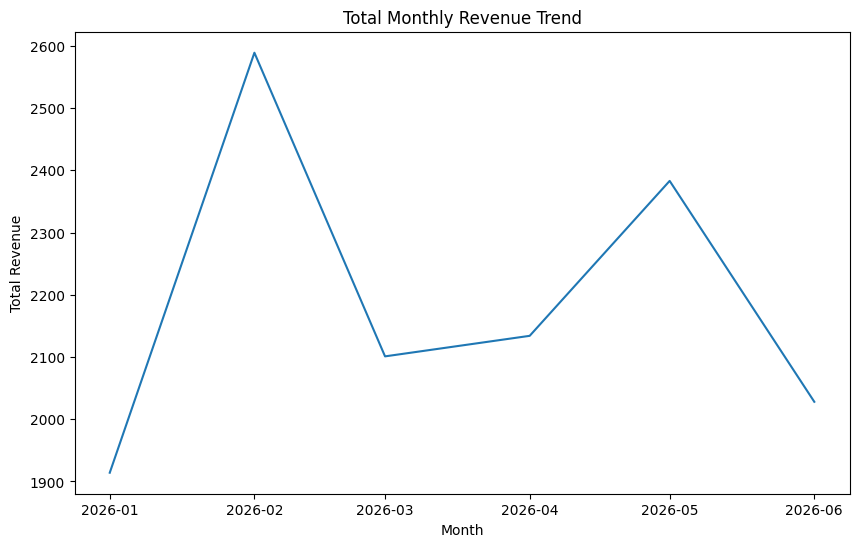

In [ ]:
# Visualization
import matplotlib.pyplot as plt
# import seaborn as sns

# Chart 1: Average order value by membership tier (bar chart)
# Tip: JOIN orders+products for total_price, JOIN customers for tier, GROUP BY tier with AVG
avg_order_value_by_tier = duckdb.sql("""
SELECT
    c.membership_tier,
    AVG(o.quantity * p.unit_price) AS avg_order_value
FROM orders_df o
JOIN products_df p ON o.product_id = p.product_id
JOIN customers_df c ON o.customer_id = c.customer_id
GROUP BY c.membership_tier
""").df().sort_values('avg_order_value', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(avg_order_value_by_tier['membership_tier'], avg_order_value_by_tier['avg_order_value'])
ax.set_title('Average Order Value by Membership Tier')
ax.set_xlabel('Membership Tier')
ax.set_ylabel('Average Order Value')
plt.show()

# Chart 2: Total monthly revenue trend (line chart)
# Tip: JOIN orders+products, GROUP BY month
total_monthly_revenue = duckdb.sql("""
SELECT
    DATE_TRUNC('month', o.order_date) AS month,
    SUM(o.quantity * p.unit_price) AS total_revenue
FROM orders_df o
JOIN products_df p ON o.product_id = p.product_id
GROUP BY month
""").df().sort_values('month', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(total_monthly_revenue['month'], total_monthly_revenue['total_revenue'])
ax.set_title('Total Monthly Revenue Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue')
plt.show()


---
# 💼 Business Insights
**What did I discover?**

- Q1 `JOIN` returns **280** order rows, not 45 unique customers. Orders use **42** of **45** ids.
  (Q1은 주문 280행. 고객 45명이 아님. 주문에 나온 id는 42명)
- High Value is **22** orders; Regular is **258**.
  (High Value는 22건, Regular는 258건)
- **9** catalog products sit above the average unit price. Chart 1 AOV is almost the same by tier (Gold **$47.95**, Regular **$47.75**, Silver **$44.26**). Chart 2 peaks in Feb (**$2,589**).
  (평균보다 비싼 상품 9개. 등급별 객단가는 거의 같음. 월 매출은 2월이 최고)
 

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Do not treat the Q1 name list as unique customers. It is **280** orders, and **3** customers never ordered.
   (Q1 이름 목록을 고객 수로 세지 말 것. 280건 주문이고, 미주문 고객 3명)
2. Do not design the store around High Value. It is **22** of **280** orders.
   (High Value를 보통 주문으로 운영하지 말 것. 280건 중 22건)
3. Do not give Gold a higher AOV target. The bars are Gold **$47.95**, Regular **$47.75**, Silver **$44.26**. Do not read Chart 2 as growth; Feb is the peak, Jun is **$2,028**.
   (Gold 객단가 목표를 더 높게 두지 말 것. 차트 2를 성장으로 읽지 말 것. 2월이 최고, 6월은 2028)
 

---
# ❌ Mistakes
**What mistakes did I make today?**

- `GROUP BY SUM(...)` is invalid. `CASE WHEN` labels each order, then `COUNT`.
  (합계로 `GROUP BY` 하면 안 됨. 주문마다 라벨 후 `COUNT`)
- Chart 2 used `sort_values(month, ascending=False)`, which plots newest month first. A trend line needs chronological order.
  (월을 내림차순하면 추세가 거꾸로 그려짐)
- Q3 is unit price vs catalog average. It is not "which products sell more."
  (Q3은 단가 vs 평균. 판매량 아님)
 

---
# ✅ What I Learned
**Today's biggest lesson**

- `JOIN ... ON` attaches lookup columns. Default is inner; here every order matched (**280**).
  (`JOIN ON`으로 이름·등급·단가를 붙임. 기본은 inner. 이번엔 주문 280건이 모두 매칭)
- `CASE WHEN` labels each order, then `GROUP BY` the label and `COUNT`. `GROUP BY` cannot take `SUM()`.
  (`CASE WHEN`으로 주문마다 라벨. 그다음 `COUNT`. 합계로 `GROUP BY` 금지)
- A subquery in `WHERE` compares each SKU to `AVG(unit_price)`. `DATE_TRUNC('month', order_date)` is Chart 2.
  (서브쿼리로 평균 단가 비교. 차트 2는 월로 자름)
 

---
# 🧠 Reflection

**What was difficult?**
`CASE WHEN` grain, and not putting `SUM()` in `GROUP BY`.
(`CASE WHEN`의 단위, `GROUP BY`에 `SUM()`을 넣는 실수)

**Why?**
The first try labeled the grand total, not each order. Q3 is catalog price, not order mix.
(처음엔 전체 합에 라벨을 붙임. Q3은 주문 구성이 아니라 카탈로그 단가)

**How did I solve it?**
Per-order `CASE WHEN` then `COUNT`. Subquery in `WHERE` for Q3. `DATE_TRUNC` for Chart 2. Sort month ascending.
(주문마다 `CASE WHEN` 후 `COUNT`. Q3은 `WHERE` 서브쿼리. 차트 2는 월로 자르고 오름차순)

**What would I do differently next time?**
Decide order vs catalog grain before `GROUP BY`. Sort a trend line by date ascending.
(`GROUP BY` 전에 주문 단위인지 카탈로그 단위인지. 추세선은 날짜 오름차순)



---
# ⭐ Self Evaluation

**Understanding**
★★★★★★☆☆☆☆
(`JOIN`·서브쿼리는 됨. `CASE WHEN` 단위는 도움 필요)

**Confidence**
★★★★★★☆☆☆☆

**Difficulty**
★★★★★★☆☆☆☆
(`GROUP BY`에 무엇을 넣는지가 더 어려웠음)


---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 09 — visualization storytelling
  (차트 스토리텔링)
 